In [25]:
# Import the required modules
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [26]:
# Import data
df = pd.read_csv('C:\\Users\\nona2\\OneDrive\\Desktop\\AI BOOTCAMP\\Project 2\\pet_adoption_data.csv')

# Read in data and index by date
df

,PetID,PetType,Breed,AgeMonths,Color,Size,WeightKg,Vaccinated,HealthCondition,TimeInShelterDays,AdoptionFee,PreviousOwner,AdoptionLikelihood
0,500,Bird,Parakeet,131,Orange,Large,5.039768,1,0,27,140,0,0
1,501,Rabbit,Rabbit,73,White,Large,16.086727,0,0,8,235,0,0
2,502,Dog,Golden Retriever,136,Orange,Medium,2.076286,0,0,85,385,0,0
3,503,Bird,Parakeet,97,White,Small,3.339423,0,0,61,217,1,0
4,504,Rabbit,Rabbit,123,Gray,Large,20.498100,0,0,28,14,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2002,2502,Dog,Poodle,72,Orange,Small,27.039045,1,0,66,26,1,1
2003,2503,Rabbit,Rabbit,124,Brown,Small,4.726954,1,1,59,150,0,0
2004,2504,Rabbit,Rabbit,113,Orange,Small,1.758592,1,0,68,302,0,0
2005,2505,Dog,Labrador,12,Gray,Large,20.961592,1,0,59,478,0,0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   object 
 2   Breed               2007 non-null   object 
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   object 
 5   Size                2007 non-null   object 
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 204.0+ KB


In [28]:
df.isnull().sum()

PetID                 0
PetType               0
Breed                 0
AgeMonths             0
Color                 0
Size                  0
WeightKg              0
Vaccinated            0
HealthCondition       0
TimeInShelterDays     0
AdoptionFee           0
PreviousOwner         0
AdoptionLikelihood    0
dtype: int64

### Is there a correlation between the pet's breed and its adoption status?


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

C:\Users\nona2\AppData\Local\Temp\ipykernel_13864\3870024853.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  adoption_by_breed = sns.barplot(x= "Breed", y= "AdoptionLikelihood", data = sorted_df, ci = None)


<Axes: xlabel='Breed', ylabel='AdoptionLikelihood'>

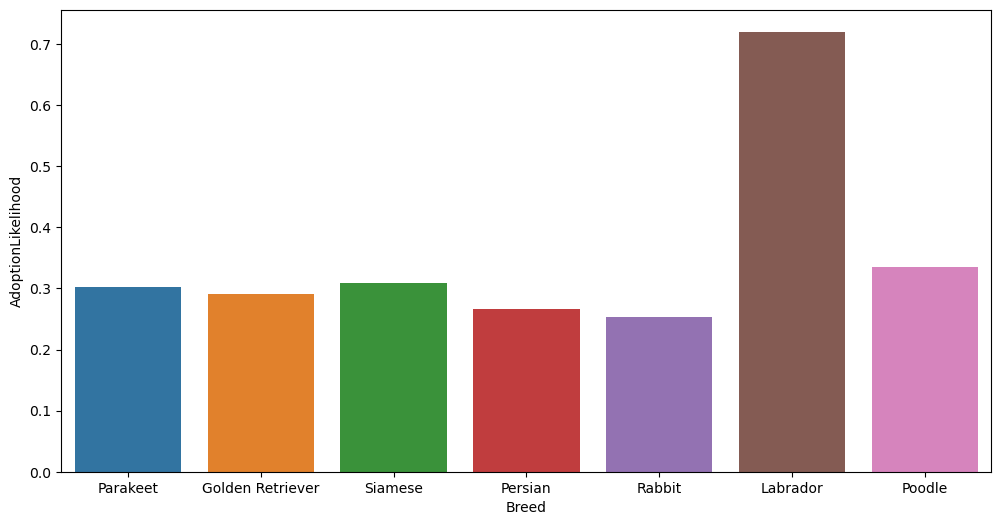

In [30]:
plt.figure(figsize = (12,6))
sorted_df = df.sort_values(by = "AdoptionLikelihood")
adoption_by_breed = sns.barplot(x= "Breed", y= "AdoptionLikelihood", data = sorted_df, ci = None)
adoption_by_breed

### Do specific attributes like color, breed, or health status impact adoption rates? 


In [31]:
from scipy.stats import chi2_contingency 

In [32]:
def chi_score(column, df):
    """
    Funcion for getting statistics between categorical variables as well as
    """
    contingency_table = pd.crosstab(df[column], df['AdoptionLikelihood'])
    print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # larger value the more significant
    print("-" * 60)
    print(f"chi2 value {column}, {chi2}")
    # degrees of freedom
    print(f"dof for {column}, {dof}")
    print("-" * 60)
    print("\n")
    # Expected Frequencies:Counts you would expect if there were no association between the variables
    print(f"expected, {column} {expected}")
    print("-" * 60)
    # p value are they statistically significant 0.05 <
    print(f'Chi-Square {column} Test p-value: {p}')
    print("-" * 60)
chi_score("Breed", df)

AdoptionLikelihood    0    1
Breed                       
Golden Retriever    115   47
Labrador             54  139
Parakeet            340  147
Persian             185   67
Poodle              111   56
Rabbit              368  125
Siamese             175   78
------------------------------------------------------------
chi2 value Breed, 154.46960684476213
dof for Breed, 6
------------------------------------------------------------


expected, Breed [[108.80717489  53.19282511]
 [129.62830095  63.37169905]
 [327.09317389 159.90682611]
 [169.25560538  82.74439462]
 [112.16542103  54.83457897]
 [331.12306926 161.87693074]
 [169.92725461  83.07274539]]
------------------------------------------------------------
Chi-Square Breed Test p-value: 8.773886416003732e-31
------------------------------------------------------------


In [33]:
def chi_score(column, df):
    """
    Funcion for getting statistics between categorical variables as well as
    """
    contingency_table = pd.crosstab(df[column], df['AdoptionLikelihood'])
    print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # larger value the more significant
    print("-" * 60)
    print(f"chi2 value {column}, {chi2}")
    # degrees of freedom
    print(f"dof for {column}, {dof}")
    print("-" * 60)
    print("\n")
    # Expected Frequencies:Counts you would expect if there were no association between the variables
    print(f"expected, {column} {expected}")
    print("-" * 60)
    # p value are they statistically significant 0.05 <
    print(f'Chi-Square {column} Test p-value: {p}')
    print("-" * 60)
chi_score("Color", df)

AdoptionLikelihood    0    1
Color                       
Black               260  135
Brown               258  125
Gray                263  137
Orange              267  142
White               300  120
------------------------------------------------------------
chi2 value Color, 4.812689904113482
dof for Color, 4
------------------------------------------------------------


expected, Color [[265.30144494 129.69855506]
 [257.24165421 125.75834579]
 [268.65969108 131.34030892]
 [274.70453413 134.29546587]
 [282.09267564 137.90732436]]
------------------------------------------------------------
Chi-Square Color Test p-value: 0.30706215359395966
------------------------------------------------------------


In [34]:
def chi_score(column, df):
    """
    Funcion for getting statistics between categorical variables as well as
    """
    contingency_table = pd.crosstab(df[column], df['AdoptionLikelihood'])
    print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # larger value the more significant
    print("-" * 60)
    print(f"chi2 value {column}, {chi2}")
    # degrees of freedom
    print(f"dof for {column}, {dof}")
    print("-" * 60)
    print("\n")
    # Expected Frequencies:Counts you would expect if there were no association between the variables
    print(f"expected, {column} {expected}")
    print("-" * 60)
    # p value are they statistically significant 0.05 <
    print(f'Chi-Square {column} Test p-value: {p}')
    print("-" * 60)
chi_score("HealthCondition", df)

AdoptionLikelihood    0    1
HealthCondition             
0                   992  621
1                   356   38
------------------------------------------------------------
chi2 value HealthCondition, 118.24403198228453
dof for HealthCondition, 1
------------------------------------------------------------


expected, HealthCondition [[1083.37020429  529.62979571]
 [ 264.62979571  129.37020429]]
------------------------------------------------------------
Chi-Square HealthCondition Test p-value: 1.5331578569746705e-27
------------------------------------------------------------


In [35]:
def chi_score(column, df):
    """
    Funcion for getting statistics between categorical variables as well as
    """
    contingency_table = pd.crosstab(df[column], df['AdoptionLikelihood'])
    print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # larger value the more significant
    print("-" * 60)
    print(f"chi2 value {column}, {chi2}")
    # degrees of freedom
    print(f"dof for {column}, {dof}")
    print("-" * 60)
    print("\n")
    # Expected Frequencies:Counts you would expect if there were no association between the variables
    print(f"expected, {column} {expected}")
    print("-" * 60)
    # p value are they statistically significant 0.05 <
    print(f'Chi-Square {column} Test p-value: {p}')
    print("-" * 60)
chi_score("Size", df)

AdoptionLikelihood    0    1
Size                        
Large               533   97
Medium              269  445
Small               546  117
------------------------------------------------------------
chi2 value Size, 437.77216119932746
dof for Size, 2
------------------------------------------------------------


expected, Size [[423.13901345 206.86098655]
 [479.55754858 234.44245142]
 [445.30343797 217.69656203]]
------------------------------------------------------------
Chi-Square Size Test p-value: 8.689264757060688e-96
------------------------------------------------------------


In [36]:
## Strongest correlationfromstrongest to weakest.
# Chi-Square Size Test (strongest association)
# Chi-Square Breed Test
# Chi-Square HealthCondition Test
# Chi-Square Color Test (weakest association)

In [37]:
def chi_score(column, df):
    """
    Funcion for getting statistics between categorical variables as well as
    """
    contingency_table = pd.crosstab(df[column], df['AdoptionLikelihood'])
    print(contingency_table)
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # larger value the more significant
    print("-" * 60)
    print(f"chi2 value {column}, {chi2}")
    # degrees of freedom
    print(f"dof for {column}, {dof}")
    print("-" * 60)
    print("\n")
    # Expected Frequencies:Counts you would expect if there were no association between the variables
    print(f"expected, {column} {expected}")
    print("-" * 60)
    # p value are they statistically significant 0.05 <
    print(f'Chi-Square {column} Test p-value: {p}')
    print("-" * 60)
chi_score("AgeMonths", df)

AdoptionLikelihood   0   1
AgeMonths                 
1                    0   7
2                    4   7
3                    5   8
4                    6  11
5                    4   7
...                 ..  ..
175                 14   2
176                 10   0
177                  5   3
178                  7   4
179                 10   4

[179 rows x 2 columns]
------------------------------------------------------------
chi2 value AgeMonths, 357.8983277193064
dof for AgeMonths, 178
------------------------------------------------------------


expected, AgeMonths [[ 4.70154459  2.29845541]
 [ 7.3881415   3.6118585 ]
 [ 8.73143996  4.26856004]
 [11.41803687  5.58196313]
 [ 7.3881415   3.6118585 ]
 [ 4.70154459  2.29845541]
 [ 6.04484305  2.95515695]
 [12.76133533  6.23866467]
 [ 4.02989537  1.97010463]
 [ 7.3881415   3.6118585 ]
 [ 6.04484305  2.95515695]
 [11.41803687  5.58196313]
 [ 9.40308919  4.59691081]
 [ 6.71649228  3.28350772]
 [ 4.70154459  2.29845541]
 [ 8.05979073

### Based on the p-values provided, we can order the strength of the association from highest to least. The smaller the p-value, the stronger the evidence against the null hypothesis, indicating a more significant association. Here’s the order from strongest to weakest association:

#### Chi-Square Size Test p-value: 8.689264757060688e-96
#### Chi-Square Breed Test p-value: 8.773886416003732e-31#### Chi-Square HealthCondition Test p-value: 1.5331578569746705e-27#### Chi-Square AgeMonths Test p-value: 3.505833751024339e-14#### Chi-Square Color Test p-value: 0.30706215359395966

## So, the order is:

#### Chi-Square Size Test (strongest association)
#### Chi-Square Breed Test
#### Chi-Square HealthCondition Test
#### Chi-Square AgeMonths Test
#### Chi-Square Color Test (weakest association)




